In [3]:
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

DATA_DIR = Path("../data/mvtec/leather")

In [4]:
splits = ["train", "test"]
for split in splits:
    split_path = DATA_DIR / split
    print(f"\n{split.upper()}")
    for category in sorted(os.listdir(split_path)):
        count = len(os.listdir(split_path / category))
        print(f"  {category}: {count} images")


TRAIN
  good: 245 images

TEST
  color: 19 images
  cut: 19 images
  fold: 17 images
  glue: 19 images
  good: 32 images
  poke: 18 images


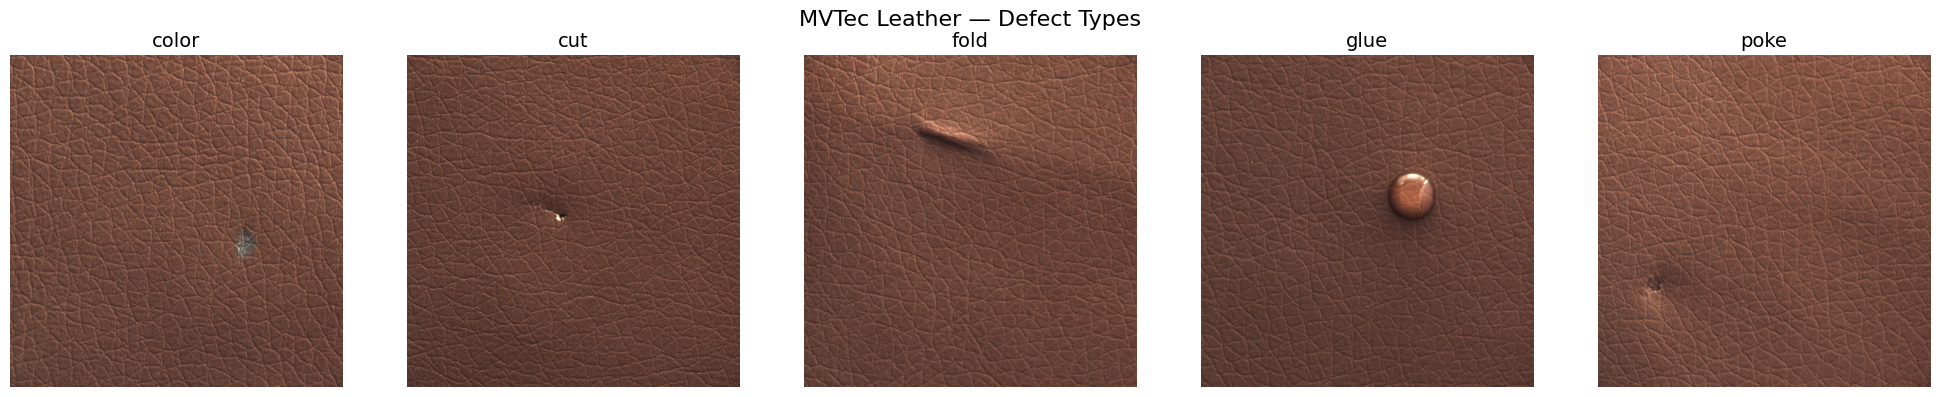

In [5]:
defect_types = ["color", "cut", "fold", "glue", "poke"]
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for ax, defect in zip(axes, defect_types):
    folder = DATA_DIR / "test" / defect
    img_path = list(folder.glob("*.png"))[0]
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(defect, fontsize=14)
    ax.axis("off")

plt.suptitle("MVTec Leather — Defect Types", fontsize=16)
plt.tight_layout()
plt.savefig("../results/defect_overview.png", dpi=150)
plt.show()

In [6]:
sample = list((DATA_DIR / "train" / "good").glob("*.png"))[0]
img = cv2.imread(str(sample))
print("Image shape:", img.shape)
print("dtype:", img.dtype)

Image shape: (1024, 1024, 3)
dtype: uint8


In [7]:

# scripts/prepare_lora_data.py
import os, cv2, shutil
from pathlib import Path

DATA_DIR = Path('data/mvtec/leather')
OUTPUT_DIR = Path('data/lora_training')

defect_types = ['color', 'cut', 'fold', 'glue', 'poke']

for defect in defect_types:
    # kohya_ss expects folder named: '10_<trigger_word>'
    # 10 = number of repeats during training
    out_folder = OUTPUT_DIR / f'10_leather_{defect}_defect'
    out_folder.mkdir(parents=True, exist_ok=True)
    
    src = DATA_DIR / 'test' / defect
    for img_path in src.glob('*.png'):
        img = cv2.imread(str(img_path))
        img = cv2.resize(img, (512, 512))  # SD 1.5 uses 512x512
        cv2.imwrite(str(out_folder / img_path.name), img)
    
    print(f'{defect}: {len(list(out_folder.glob("*.png")))} images prepared')

print('Done! Upload data/lora_training/ to Kaggle.')


color: 0 images prepared
cut: 0 images prepared
fold: 0 images prepared
glue: 0 images prepared
poke: 0 images prepared
Done! Upload data/lora_training/ to Kaggle.
